Dataset Preview:


,Accident_Index,Accident Date,Day_of_Week,Junction_Control,Junction_Detail,Accident_Severity,Latitude,Light_Conditions,Local_Authority_(District),Carriageway_Hazards,...,Number_of_Casualties,Number_of_Vehicles,Police_Force,Road_Surface_Conditions,Road_Type,Speed_limit,Time,Urban_or_Rural_Area,Weather_Conditions,Vehicle_Type
0,BS0000001,01-01-2021,Thursday,Give way or uncontrolled,T or staggered junction,Serious,51.512273,Daylight,Kensington and Chelsea,NaN,...,1,2,Metropolitan Police,Dry,One way street,30,15:11,Urban,Fine no high winds,Car
1,BS0000002,05-01-2021,Monday,Give way or uncontrolled,Crossroads,Serious,51.514399,Daylight,Kensington and Chelsea,NaN,...,11,2,Metropolitan Police,Wet or damp,Single carriageway,30,10:59,Urban,Fine no high winds,Taxi/Private hire car
2,BS0000003,04-01-2021,Sunday,Give way or uncontrolled,T or staggered junction,Slight,51.486668,Daylight,Kensington and Chelsea,NaN,...,1,2,Metropolitan Police,Dry,Single carriageway,30,14:19,Urban,Fine no high winds,Taxi/Private hire car
3,BS0000004,05-01-2021,Monday,Auto traffic signal,T or staggered junction,Serious,51.507804,Daylight,Kensington and Chelsea,NaN,...,1,2,Metropolitan Police,Frost or ice,Single carriageway,30,08:10,Urban,Other,Motorcycle over 500cc
4,BS0000005,06-01-2021,Tuesday,Auto traffic signal,Crossroads,Serious,51.482076,Darkness - lights lit,Kensington and Chelsea,NaN,...,1,2,Metropolitan Police,Dry,Single carriageway,30,17:25,Urban,Fine no high winds,Car


Dataset Shape: (307973, 21)
Columns: Index(['Accident_Index', 'Accident Date', 'Day_of_Week', 'Junction_Control',
       'Junction_Detail', 'Accident_Severity', 'Latitude', 'Light_Conditions',
       'Local_Authority_(District)', 'Carriageway_Hazards', 'Longitude',
       'Number_of_Casualties', 'Number_of_Vehicles', 'Police_Force',
       'Road_Surface_Conditions', 'Road_Type', 'Speed_limit', 'Time',
       'Urban_or_Rural_Area', 'Weather_Conditions', 'Vehicle_Type'],
      dtype='object')
Accident_Severity     0
Weather_Conditions    0
Light_Conditions      0
Junction_Detail       0
Speed_limit           0
dtype: int64
Remaining rows: (307973, 5)
Accident_Severity
Slight    263280
Fatal       3953
Name: count, dtype: int64


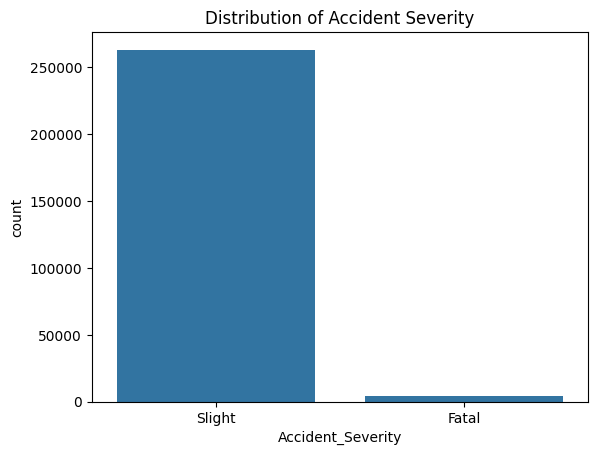

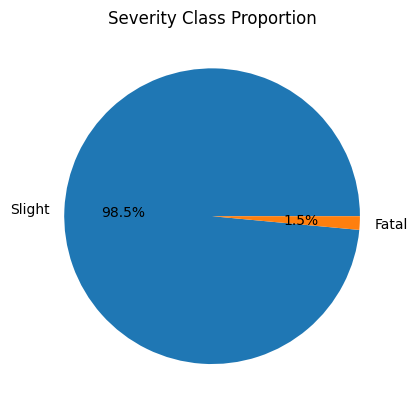

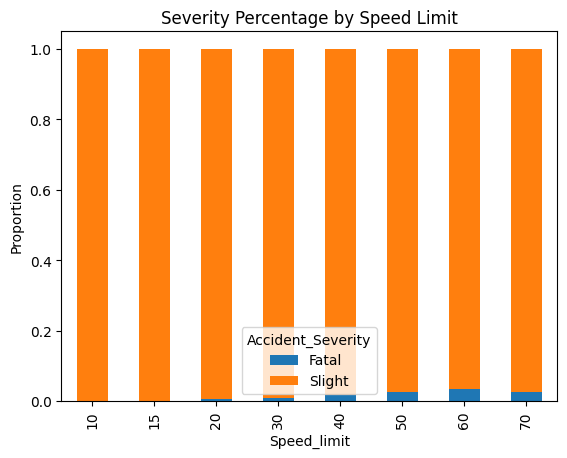

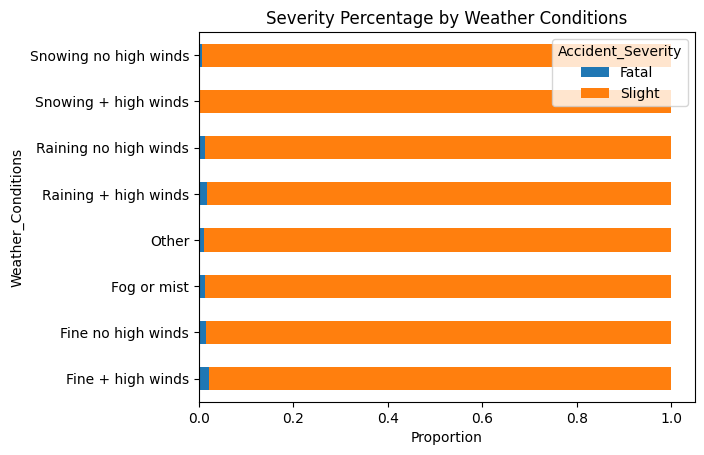

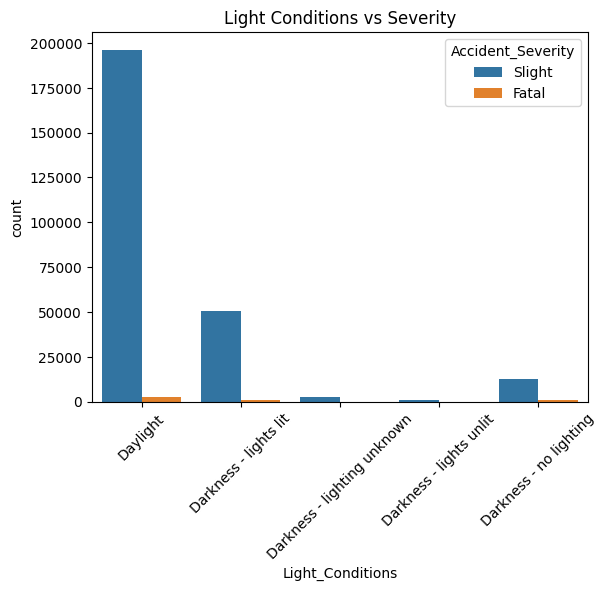

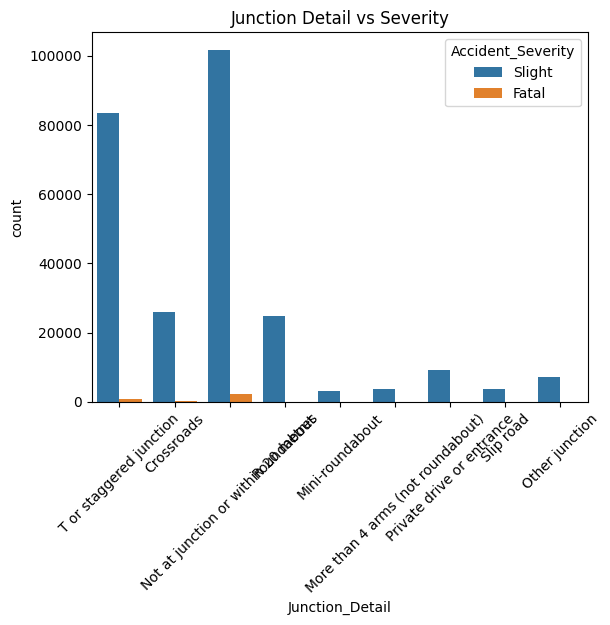

,Speed_limit,Weather_Conditions_Fine no high winds,Weather_Conditions_Fog or mist,Weather_Conditions_Other,Weather_Conditions_Raining + high winds,Weather_Conditions_Raining no high winds,Weather_Conditions_Snowing + high winds,Weather_Conditions_Snowing no high winds,Light_Conditions_Darkness - lights lit,Light_Conditions_Darkness - lights unlit,Light_Conditions_Darkness - no lighting,Light_Conditions_Daylight,Junction_Detail_Mini-roundabout,Junction_Detail_More than 4 arms (not roundabout),Junction_Detail_Not at junction or within 20 metres,Junction_Detail_Other junction,Junction_Detail_Private drive or entrance,Junction_Detail_Roundabout,Junction_Detail_Slip road,Junction_Detail_T or staggered junction
2,30,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True
5,30,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True
7,30,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False
8,30,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True
9,30,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False


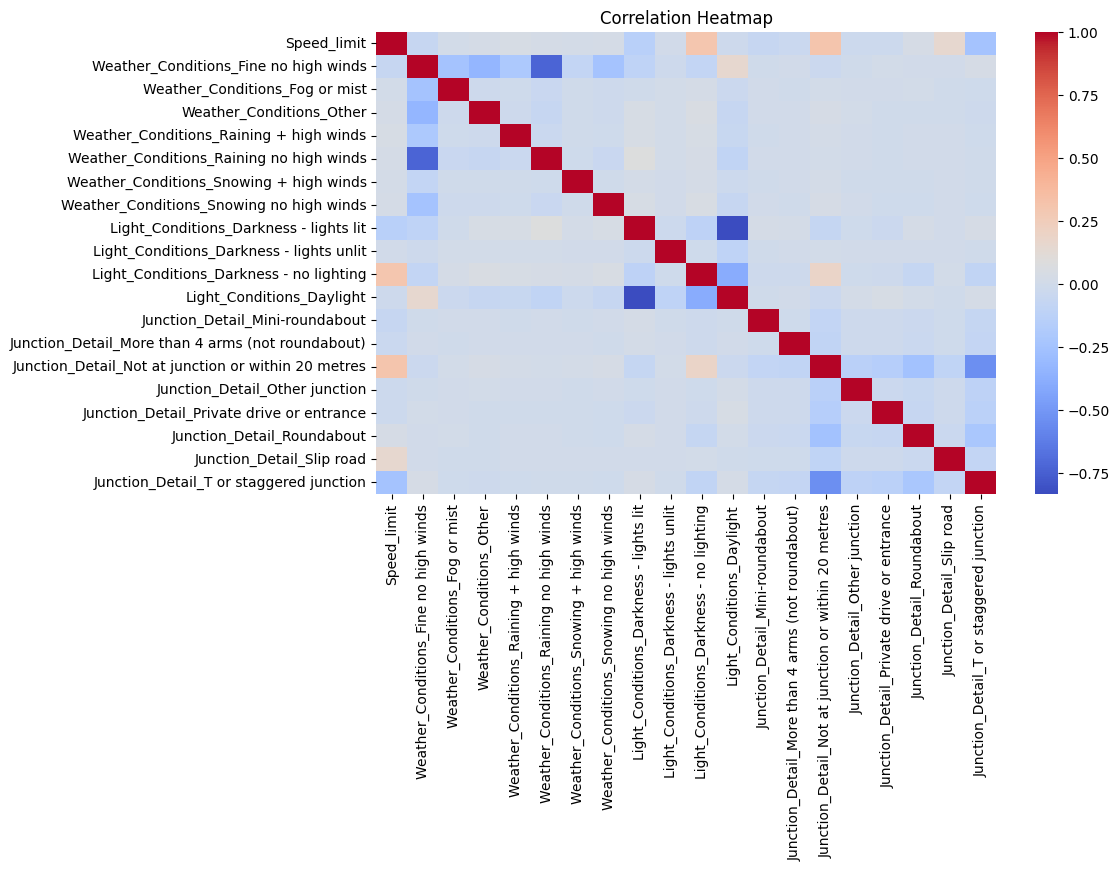


 Logistic Regression
Accuracy: 0.9852002918779351
              precision    recall  f1-score   support

           0       0.99      1.00      0.99     52656
           1       0.00      0.00      0.00       791

    accuracy                           0.99     53447
   macro avg       0.49      0.50      0.50     53447
weighted avg       0.97      0.99      0.98     53447


 Decision Tree
Accuracy: 0.9852002918779351
              precision    recall  f1-score   support

           0       0.99      1.00      0.99     52656
           1       0.00      0.00      0.00       791

    accuracy                           0.99     53447
   macro avg       0.49      0.50      0.50     53447
weighted avg       0.97      0.99      0.98     53447


 Random Forest
Accuracy: 0.7170467940202444
              precision    recall  f1-score   support

           0       0.99      0.72      0.83     52656
           1       0.03      0.60      0.06       791

    accuracy                           0.

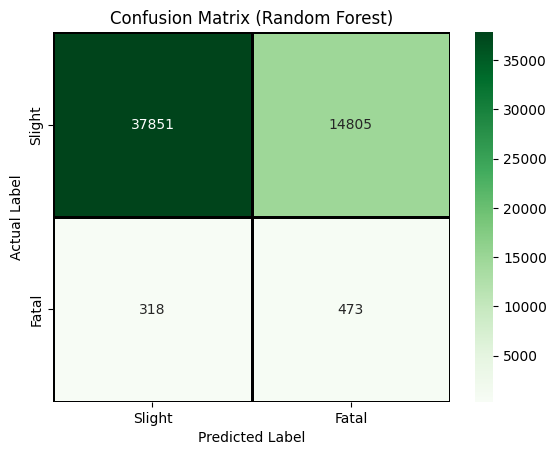

,Feature,Importance
0,Speed_limit,0.426127
14,Junction_Detail_Not at junction or within 20 m...,0.114339
17,Junction_Detail_Roundabout,0.092322
10,Light_Conditions_Darkness - no lighting,0.073686
11,Light_Conditions_Daylight,0.060749
8,Light_Conditions_Darkness - lights lit,0.035870
19,Junction_Detail_T or staggered junction,0.028838
1,Weather_Conditions_Fine no high winds,0.028629
5,Weather_Conditions_Raining no high winds,0.018940
7,Weather_Conditions_Snowing no high winds,0.016001


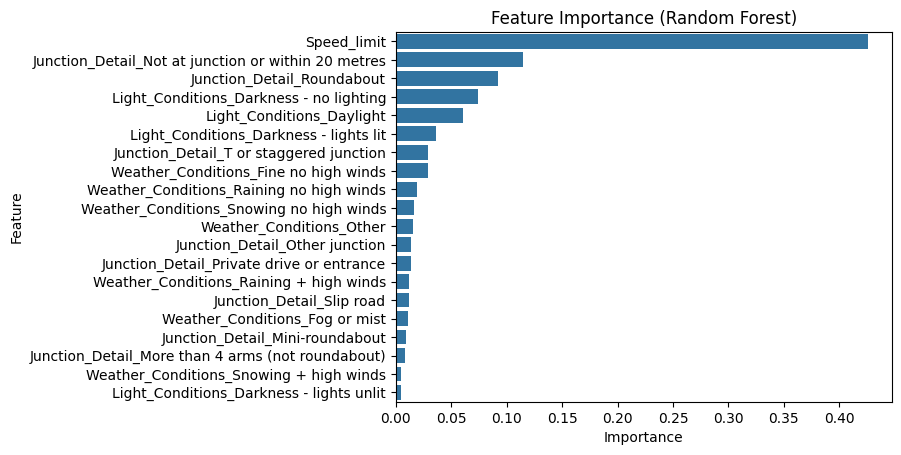

Recall for Fatal accidents is prioritized because
missing fatal crashes is more serious than false alarms.
Model training complete.


In [7]:
#Can machine learning models classify accident severity using Weather, Light Conditions, Junction Detail, and Speed Limit—and which feature best predicts fatal vs slight outcomes?
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

import warnings
warnings.filterwarnings("ignore")
# SECTION 2: LOAD DATASET
df = pd.read_csv("Road Accident Data.csv")

print("Dataset Preview:")
display(df.head())

print("Dataset Shape:", df.shape)
print("Columns:", df.columns)

# SECTION 3: SELECT RELEVANT FEATURES
selected_columns = [
    "Accident_Severity",
    "Weather_Conditions",
    "Light_Conditions",
    "Junction_Detail",
    "Speed_limit"
]

accident_df = df[selected_columns].copy()
# SECTION 4: DATA CLEANING
accident_df["Accident_Severity"] = accident_df["Accident_Severity"].replace("Fetal", "Fatal")

# Replace dataset-specific missing values
missing_strings = [
    "Unknown",
    "Missing",
    "NA",
    "",
    "Data missing or out of range"
]

accident_df.replace(missing_strings, np.nan, inplace=True)

print(accident_df.isnull().sum())

# Drop missing rows
accident_df.dropna(inplace=True)

print("Remaining rows:", accident_df.shape)
# SECTION 5: FILTER TARGET VARIABLE

accident_df = accident_df[
    accident_df["Accident_Severity"].isin(["Fatal", "Slight"])
]

print(accident_df["Accident_Severity"].value_counts())
# SECTION 6: EDA GRAPH 1 — BAR (Severity Distribution)
sns.countplot(x="Accident_Severity", data=accident_df)
plt.title("Distribution of Accident Severity")
plt.show()
# SECTION 7: EDA GRAPH 2 — PIE (Class Proportion)

accident_df["Accident_Severity"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Severity Class Proportion")
plt.ylabel("")
plt.show()

# SECTION 8: EDA GRAPH 3 — STACKED BAR (Speed Limit vs Severity)
speed_percent = pd.crosstab(
    accident_df["Speed_limit"],
    accident_df["Accident_Severity"],
    normalize="index"
)

speed_percent.plot(
    kind="bar",
    stacked=True
)

plt.title("Severity Percentage by Speed Limit")
plt.ylabel("Proportion")
plt.show()

# SECTION 9: EDA GRAPH 4 — HORIZONTAL STACKED BAR (Weather)

weather_percent = pd.crosstab(
    accident_df["Weather_Conditions"],
    accident_df["Accident_Severity"],
    normalize="index"
)

weather_percent.plot(
    kind="barh",
    stacked=True
)

plt.title("Severity Percentage by Weather Conditions")
plt.xlabel("Proportion")
plt.show()

# SECTION 10: EDA GRAPH 5 — BAR (Light Conditions)

sns.countplot(
    x="Light_Conditions",
    hue="Accident_Severity",
    data=accident_df
)

plt.title("Light Conditions vs Severity")
plt.xticks(rotation=45)
plt.show()
# SECTION 11: EDA GRAPH 6 — BAR (Junction Detail)

sns.countplot(
    x="Junction_Detail",
    hue="Accident_Severity",
    data=accident_df
)

plt.title("Junction Detail vs Severity")
plt.xticks(rotation=45)
plt.show()

# SECTION 12: TARGET VARIABLE (Fatal = 1)

y = accident_df["Accident_Severity"].map({
    "Fatal": 1,
    "Slight": 0
})

# SECTION 13: ONE-HOT ENCODING FEATURES

X = pd.get_dummies(
    accident_df.drop("Accident_Severity", axis=1),
    drop_first=True
)

display(X.head())
# SECTION 14: CORRELATION HEATMAP

plt.figure(figsize=(10,6))
sns.heatmap(X.corr(), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# SECTION 15: TRAIN TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    stratify=y,
    test_size=0.2,
    random_state=42
)


# SECTION 16: TRAIN MODELS

log_model = LogisticRegression(max_iter=1000)
tree_model = DecisionTreeClassifier(max_depth=5)

rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42
)

log_model.fit(X_train, y_train)
tree_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)
# SECTION 17: MODEL EVALUATION

models = {
    "Logistic Regression": log_model,
    "Decision Tree": tree_model,
    "Random Forest": rf_model
}

for name, model in models.items():

    predictions = model.predict(X_test)

    print("\n", name)
    print("Accuracy:", accuracy_score(y_test, predictions))
    print(classification_report(y_test, predictions))
# SECTION 18: CONFUSION MATRIX

# SECTION 18: CONFUSION MATRIX

predictions = rf_model.predict(X_test)

cm = confusion_matrix(y_test, predictions)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["Slight", "Fatal"],
    yticklabels=["Slight", "Fatal"],
    linewidths=1,
    linecolor="black"
)

plt.title("Confusion Matrix (Random Forest)")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()
# SECTION 19: FEATURE IMPORTANCE

importance = rf_model.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

display(feature_importance)
# SECTION 20: FEATURE IMPORTANCE GRAPH

sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_importance
)

plt.title("Feature Importance (Random Forest)")
plt.show()
# SECTION 21: POLICY INTERPRETATION NOTE

print("Recall for Fatal accidents is prioritized because")
print("missing fatal crashes is more serious than false alarms.")

print("Model training complete.")